##### MHKiT Hindcast Resource Assessment

Original Author: Hannah Mankle 

This Jupyter notebook uses NREL's MHKiT toolbox to perform resource assessments using data from the MHKiT Hindcast Database. https://registry.opendata.aws/wpto-pds-us-wave/

All files are virtual buoys along coastlines of the US with 3-hour temporal resolutions to a 200m spatial resoution. PWS data is pulled with the 1-hour temporal resoulions which includes direction wave spectrum data in HDF5 format.

Currently MHKiT pulls the Hindcast data from AWS and cannot complete a request for 10+ years of data. Data for the locations beflow have been pulled from AWS and saved to .CSV files to complete assessments that meet IEC standards. Figures on these locations can be found in the Graphics folder under each location. General information from this assessment can be found in the Resource Conditions folder in the parent directory.

Note: AK, HI & Miami do not have mean zero-crossing period in dataset -> do not calculate wave steepness. AK does not have files for 1979,1991,2010

The current version of MHKiT used to run this code is a fork of the main MHKiT repository. Please install the version of MHKiT from https://github.com/camirmas/MHKiT-Python if you want to pull directly from the local .h5 files. 

In [1]:
# Importing necessary python packages

from mhkit import wave
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import numpy as np
import folium
import requests
import os
# from windrose import WindroseAxes, WindAxes
import matplotlib.cm as cm
import matplotlib.dates as dates
from datetime import time, datetime  
import xarray as xr

**Establish Path to Data**

In [2]:
# establishing path to data
location =  'hindcast_wave_resource_assessent'
loc = 'Neah_Bay_CSV' 
lat_lon = (48.16, -124.91)   # Lat/Lon of location -> listed above

# Generate folder paths - DO NOT CHANGE
path = os.getcwd() #current working directory
parent = os.path.join(path, os.pardir) #creating full path to parent directory

loc_folder = os.path.join(parent, 'location', loc)
wave_folder = os.path.join(loc_folder,r'Wave\virtual_buoy') #path to dataset location
hsds_path = os.path.join(loc_folder,r'Wave\virtual_buoy\West_Coast_virtual_buoy_*.h5') #path to dataset location
csv_path = os.path.join(loc_folder,r'Wave\virtual_buoy\PWS_virtual_buoy_*.csv') 
graphics_path = os.path.join(loc_folder,r'Graphics') 
power_folder = os.path.join(parent, r'SmallWEC_Data')

print("Parent Directory:", os.path.abspath(parent))
print("\nloc Directory:", os.path.abspath(loc_folder))
print("\nwave Directory:", os.path.abspath(wave_folder))
print("\ngraphic Directory: ",os.path.abspath(graphics_path))
print("\npower Folder:", os.path.abspath(power_folder)) 

Parent Directory: c:\Users\ianhe\Projects\hindcast_wave_resource_assessment

loc Directory: c:\Users\ianhe\Projects\hindcast_wave_resource_assessment\location\Neah_Bay_CSV

wave Directory: c:\Users\ianhe\Projects\hindcast_wave_resource_assessment\location\Neah_Bay_CSV\Wave\virtual_buoy

graphic Directory:  c:\Users\ianhe\Projects\hindcast_wave_resource_assessment\location\Neah_Bay_CSV\Graphics

power Folder: c:\Users\ianhe\Projects\hindcast_wave_resource_assessment\SmallWEC_Data


In [ ]:
# OPTIONAL: Create a Folium map of WEC deployment sites

m = folium.Map(
    location=[42.74053585316551, -124.49842283386084],
    zoom_start=12,
    tiles="OpenStreetMap",
    attr="Map data © OpenStreetMap contributors",
    control_scale=True,
)

tooltip = "Port of Port Orford"
folium.Marker(
    [42.739394124156874, -124.49889974623157], 
    tooltip=tooltip
).add_to(m)

# Inshore WEC Deployment Site (green icon)
tooltip = "Nearshore WEC Deployment Site"
folium.Marker(
    [42.734319, -124.498121],
    tooltip=tooltip,
    popup="<i> Water depth: ~14 m</i>, <i> Distance from shore: ~0.25 miles",
    icon=folium.Icon(color="blue", icon="bolt", prefix="fa"),
).add_to(m)

# Offshore WEC Deployment Site (green icon)
tooltip = "Offshore WEC Deployment Site"
folium.Marker(
    [42.721487, -124.506283],
    tooltip=tooltip,
    popup="<i> Water depth: ~31 m</i>, <i> Distance from shore: ~1.25 miles",
    icon=folium.Icon(color="green", icon="bolt", prefix="fa"),
).add_to(m)

m

fig_path = os.path.join(parent, 'figures', "PortOrford_WEC_Site_Map.html")
m.save(fig_path)

**Import Data from MHKit CSV**

In [13]:
# Set year range, data type, and parameters to pull from DOE repository

data_type = '3-hour' # only need if pulling data from MHKIT AWS
start_year = 1979 #AK data starts at 1985, all other locations start at 1979
end_year = 2020
all_years = list(range(start_year,end_year+1))
#all_years.remove(2010) #removing years not included at location (StPaul,Yakutat)
years = [str(x) for x in all_years]

# Parameters used when pulling data from DOE data repository
parameter = ['significant_wave_height','peak_period','energy_period', 'omni-directional_wave_power',
'mean_wave_direction','spectral_width','directionality_coefficient']

# metadata= wave.io.hindcast.hindcast.request_wpto_point_data(data_type,parameter,lat_lon,years)
# metadata


In [19]:
# Load data from CSV files, Clean Column Names

data = []
for yr in years:
    # Change filename to reflect new buoy lat, lon and number
    filename = os.path.abspath(os.path.join(wave_folder, '102698_48.16_-124.91_' + yr + '.csv')) # OFFSHORE
    # filename = os.path.abspath(os.path.join(wave_folder, '613868_42.73_-124.50_' + yr + '.csv')) #INSHORE, 0.25 MILES
    # Set header columns w/ header=2
    data.append(pd.read_csv(filename, header=2))

data = pd.concat(data)
print(data.columns.tolist())
# Clean up column names (optional but recommended)
data.columns = data.columns.str.strip()
# Create a Datetime column from Year, Month, Day, Hour, and Minute columns
data['Datetime'] = pd.to_datetime(data[['Year', 'Month', 'Day', 'Hour', 'Minute']])
# Set Datetime as the index
data = data.set_index('Datetime')
# Clean data based on SWH
data = data[data['Significant Wave Height'] <= 20]
data.dropna(inplace=True)
# Sort the DateTime index
data.sort_index(inplace=True)
# Clean up column names: lower case and replace spaces with underscores
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')
# Preserve the analysis notebook's established name for wave power.
data.rename(columns={'wave_power': 'omni-directional_wave_power'}, inplace=True)

['Year', 'Month', 'Day', 'Hour', 'Minute', 'Directionality Coefficient', 'Energy Period', 'Maximum Energy Direction', 'Mean Absolute Period', 'Mean Zero-Crossing Period', 'Wave Power', 'Peak Period', 'Significant Wave Height', 'Spectral Width']


In [14]:
filename_total = os.path.abspath(os.path.join(wave_folder,loc+'_virtual_buoy_All.csv'))
data.to_csv(filename_total)

**Setup for average annual energy matrix and monthly averages**

In [18]:
# Setup

Hm0 = data['significant_wave_height']
Te = data['energy_period']
J = data['omni-directional_wave_power']
Tp = data['peak_period']
d = data['directionality_coefficient']

data['J_tm'] = d*J
J_tm = data['J_tm'].round(2)

Tz = data['mean_zero-crossing_period'] # comment out for locations outside of the West Coast
D = pd.concat([Hm0, Tp,Te, J,J_tm],axis=1) # comment out for West Coast locations
#D = pd.concat([Hm0, Te, J, J_thetamax, Tz],axis=1) # comment out for locations outside of the West Coast 
#Hm0

# print(J.describe())

In [20]:
# Only run for West Coast locations

# Calculate wave steepness
D['Sm'] = Hm0 / (9.81/(2*np.pi) * Tz**2)

# Drop any NaNs created from the calculation of Hm0 or Te
D.dropna(inplace=True)
# Sort the DateTime index
D.sort_index(inplace=True)
# D.rename(index={0: "Hm0", 1: "Te", 2: "Tp", 3: "J", 4: "Tz"})

**Average Annaul Energy Matrix w/ Resource Frequebncy**

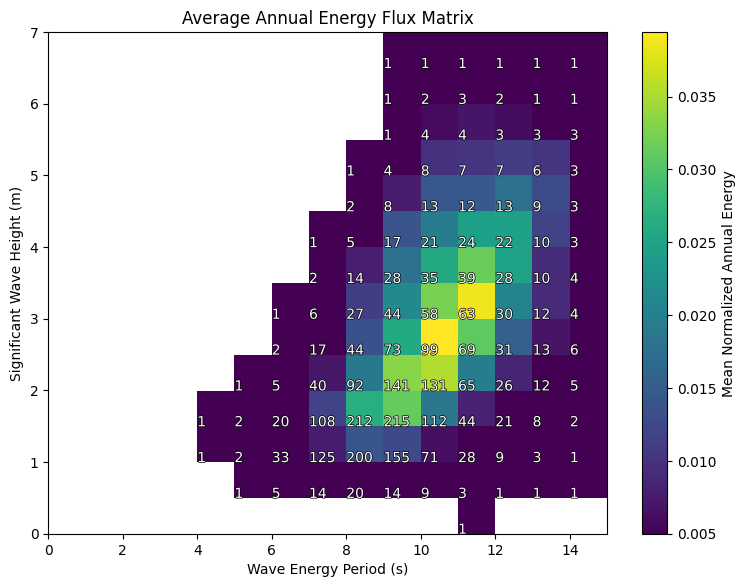

In [21]:
# Plot Average Energy Flux Matrix

# Setting the bins for the resource frequency and power distribution
Hm0_bin_size = 0.5
Hm0_edges = np.arange(0,7+Hm0_bin_size,Hm0_bin_size)
Te_bin_size = 1
Te_edges = np.arange(0, 15+Te_bin_size,Te_bin_size)
#fig = plt.figure(figsize=(12, 8))
fig = wave.graphics.plot_avg_annual_energy_matrix(D['significant_wave_height'], D['energy_period'], 
                        D['omni-directional_wave_power'], time_index=None, Hm0_edges=Hm0_edges, Te_edges=Te_edges)

plt.title("Average Annual Energy Flux Matrix")

# Needs to be Updated
figure = plt.gcf()
plt.set_cmap('viridis')
#plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])
#plt.yticks([0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0,3.25,3.5,3.75,4.0])
#plt.grid()
# exporting plot to png
figure.set_size_inches(8, 6)

fig_path = os.path.join(graphics_path,'AvgEnergyMatrix.png') 
plt.savefig(fig_path,format="png",dpi=100,bbox_inches='tight')

(15, 16)


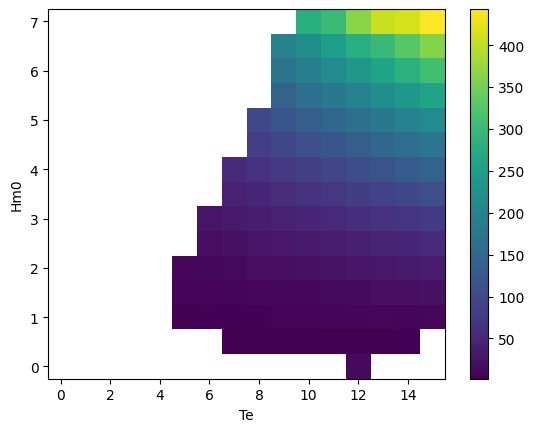

In [22]:
# Create average annual energy flux matrix using mean, convert to kW
JM_mean = wave.performance.wave_energy_flux_matrix(D['significant_wave_height'], D['energy_period'], 
                        D['omni-directional_wave_power']/1000, "mean", Hm0_bins=Hm0_edges, Te_bins=Te_edges)
print(JM_mean.shape)

# convert to x_array
JM_xr = xr.DataArray(JM_mean, dims=("Hm0", "Te"), coords={"Hm0":Hm0_edges, "Te":Te_edges})
JM_xr.plot() 


**JDP Matrix, Check**

JPD Sum:  1.0
Bin Count Sum:  93440.0


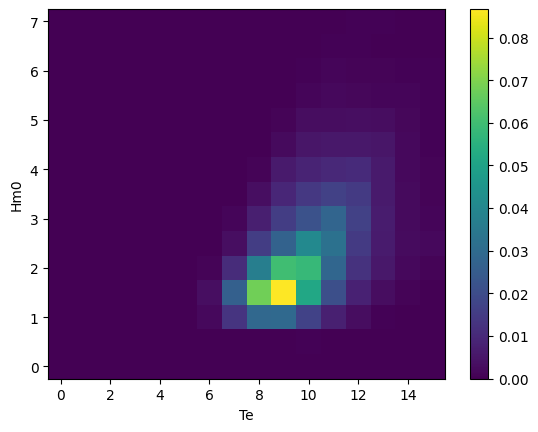

In [23]:
# Shouts out to Andrew Simm
JPD = wave.performance.capture_length_matrix(
    D['significant_wave_height'], D['energy_period'], np.zeros(len(D['significant_wave_height'])), "frequency",Hm0_bins=Hm0_edges, Te_bins=Te_edges)
# JPD.plot()

# Calculate the sum of the joint probability distribution, this should be 1
print("JPD Sum: ", JPD.sum().sum())

bin_count = wave.performance.capture_length_matrix(
    D['significant_wave_height'], D['energy_period'], np.zeros(len(D['significant_wave_height'])), "count",Hm0_bins=Hm0_edges, Te_bins=Te_edges)

# print("Bin Count Matrix:\n", bin_count)
print("Bin Count Sum: ", bin_count.sum().sum())

# convert to x_array
JDP_xr = xr.DataArray(JPD, dims=("Hm0", "Te"), coords={"Hm0":Hm0_edges, "Te":Te_edges})
JDP_xr.plot() 



**Monthly Averages**

--------------------------------------------
significant_wave_height max:2.955, month: 12
significant_wave_height max mean:3.1139, month: 12
significant_wave_height min:1.4226, month: 8
significant_wave_height min mean1.4747, month: 8
--------------------------------------------
peak_period max:13.3268, month: 1
peak_period max mean:13.404, month: 2
peak_period min:9.1017, month: 7
peak_period min mean10.5546, month: 7
--------------------------------------------
energy_period max:11.0131, month: 2
energy_period max mean:11.0474, month: 2
energy_period min:8.3194, month: 7
energy_period min mean8.4101, month: 7
--------------------------------------------
omni-directional_wave_power max:50828.5, month: 12
omni-directional_wave_power max mean:68411.9972, month: 12
omni-directional_wave_power min:9082.0, month: 8
omni-directional_wave_power min mean10458.7688, month: 8
--------------------------------------------
J_tm max:44440.53, month: 12
J_tm max mean:60758.5639, month: 12
J_tm min:7

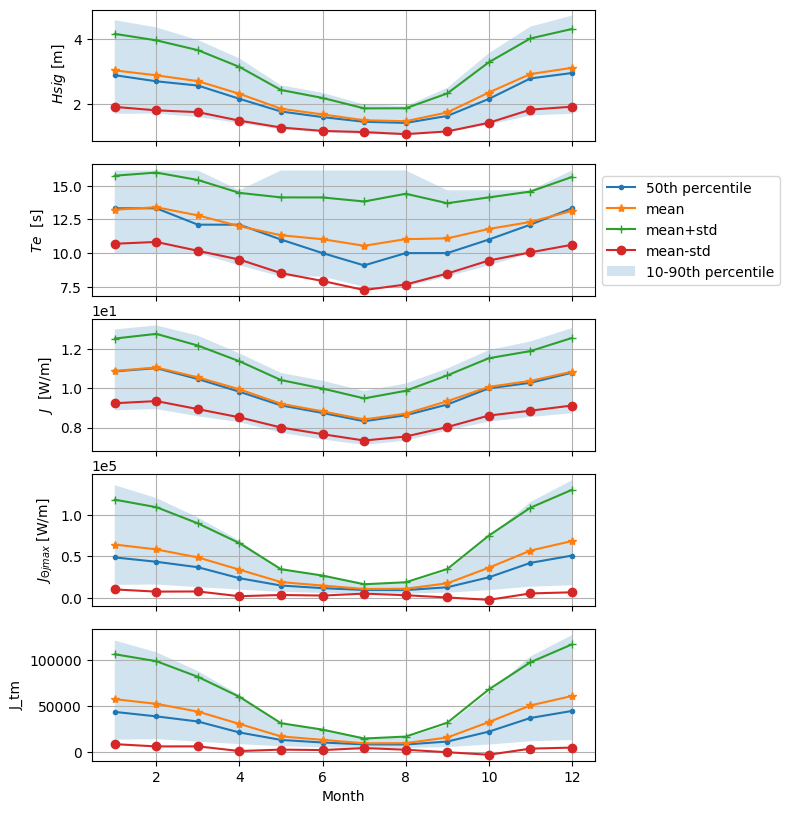

In [24]:
# Plot monthly averages

QoIs = D.keys()
fig, axs = plt.subplots(len(QoIs)-1,1, figsize=(8, 12), sharex=True)

months=D.index.month
data_group=D.groupby(months)

stdd = data_group.std()

#shade between 25% and 75%
for i in range(len(QoIs)-1):
    QoI = QoIs[i]

    axs[i].plot(data_group.median()[QoI], marker='.',label='50th percentile')
    axs[i].plot(data_group.mean()[QoI], marker='*',label='mean')
    
    axs[i].plot(data_group.mean()[QoI]+stdd[QoI],marker='+',label='mean+std')
    axs[i].plot(data_group.mean()[QoI]-stdd[QoI],marker='o',label='mean-std')
    

    axs[i].fill_between(months.unique(),
                        data_group.quantile(q=.1)[QoI],
                        data_group.quantile(q=.9)[QoI],
                        alpha=0.2,
                        label='10-90th percentile')
    axs[i].grid()

    mx = data_group.median()[QoI].max()
    mx_month= data_group.median()[QoI].argmax()+1
    mx_avg = data_group.mean()[QoI].max()
    mx_avg_month = data_group.mean()[QoI].argmax()+1
    mn = data_group.median()[QoI].min()
    mn_month= data_group.median()[QoI].argmin()+1
    mn_avg =  data_group.mean()[QoI].min()
    mn_avg_month= data_group.median()[QoI].argmin()+1
    print('--------------------------------------------')
    print(f'{QoI} max:{np.round(mx,4)}, month: {mx_month}')
    print(f'{QoI} max mean:{np.round(mx_avg,4)}, month: {mx_avg_month}')
    print(f'{QoI} min:{np.round(mn,4)}, month: {mn_month}')
    print(f'{QoI} min mean{np.round(mn_avg,4)}, month: {mn_avg_month}')
    plt.setp(axs[i], ylabel = QoIs[i])

plt.setp(axs[-1], xlabel='Month')
plt.setp(axs[0], ylabel=f' $Hsig$ [m]')
plt.setp(axs[1], ylabel=f'$Te$  [s]')
plt.setp(axs[2], ylabel=f'$J$  [W/m]')
plt.setp(axs[3], ylabel=r'$J_{\Theta jmax}$ [W/m]')

axs[3].ticklabel_format(axis='y',style='sci',scilimits=(1,4))
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[2].ticklabel_format(axis='y',style='sci',scilimits=(1,5))


plt.tight_layout()

# Needs to be Updated
figure = plt.gcf()
# exporting plot to png
figure.set_size_inches(8, 8)
fig_path = os.path.join(graphics_path,'MonthlyAvgs.png')
plt.savefig(fig_path, dpi=100,bbox_inches='tight')


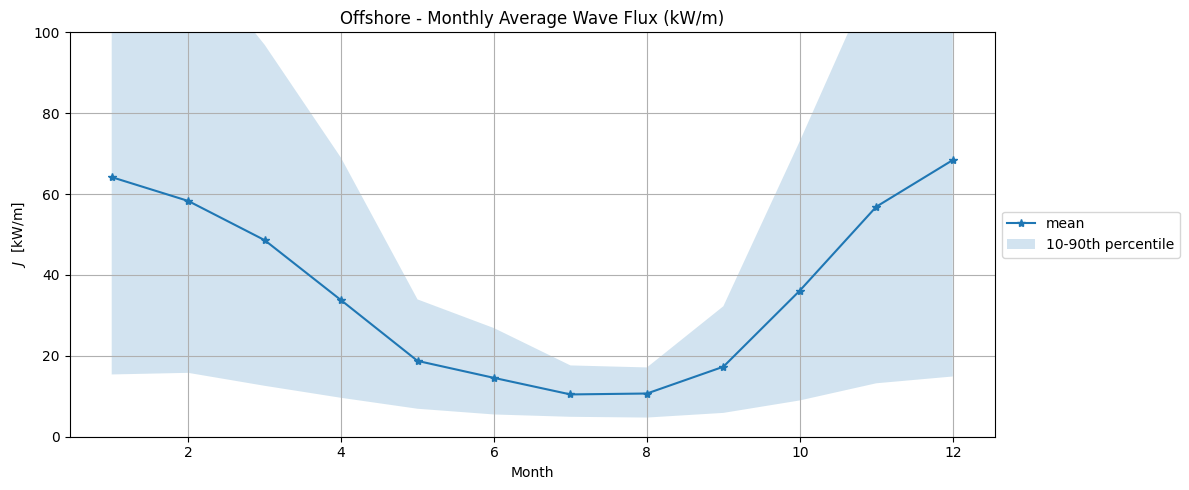

In [25]:
# Just plot Monthly Average Wave Flux in kW/m

J = data['omni-directional_wave_power'] / 1000  # Convert from W/m to kW/m
months = J.index.month
data_group = J.groupby(months)
stdd = data_group.std()

fig, ax = plt.subplots(figsize=(12,5), sharex=True)

# Plot mean
ax.plot(data_group.mean(), marker='*', label='mean')

# Shade between 10th and 90th percentile
ax.fill_between(
    months.unique(),
    data_group.quantile(q=0.1),
    data_group.quantile(q=0.9),
    alpha=0.2,
    label='10-90th percentile'
)
ax.grid()
# Axis labels and legend
ax.set_xlabel('Month')
ax.set_ylabel('$J$  [kW/m]')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.ticklabel_format(axis='y', style='plain')
ax.set_ylim(0, 100)

ax.set_title('Offshore - Monthly Average Wave Flux (kW/m)')
# ax.set_title('Inshore - Monthly Average Wave Flux (kW/m)')
plt.tight_layout()

# Exporting plot to png
# figure = plt.gcf()
# figure.set_size_inches(8, 6)
# fig_path = os.path.join(graphics_path, 'MonthlyAvg_J_kWm.png')
# plt.savefig(fig_path, dpi=100, bbox_inches='tight')


**Monthly Cumulative Distribution**

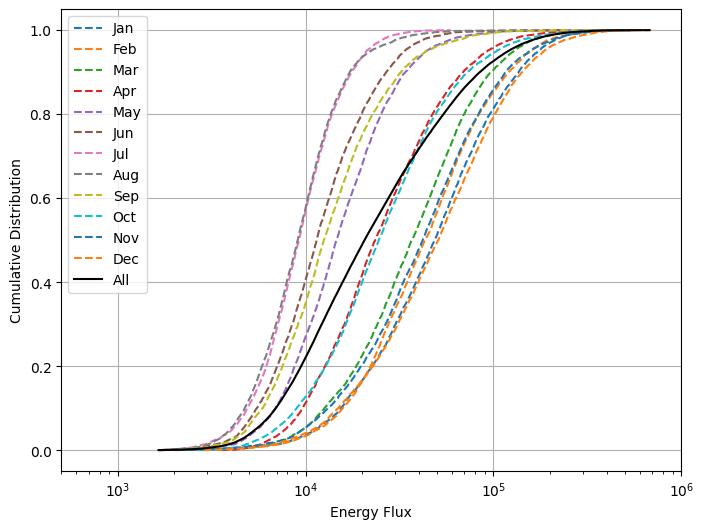

In [27]:
ax = wave.graphics.monthly_cumulative_distribution(D['omni-directional_wave_power'])
plt.xlim([500, 1E6])

# Needs to be Updated
figure = plt.gcf()
# exporting plot to png
figure.set_size_inches(8, 6)
fig_path = os.path.join(graphics_path,'MonthlyCumulativeDist.png') 
plt.savefig(fig_path,format="png",dpi=100,bbox_inches='tight')

**Small WEC JSON Reader - Capture Length Matrix**

In [ ]:
# # Manual load in WEC Capture width matrix w/ path co

# # Change these two lines...
# wec_name  = '4m_scale_rm3'
# file_name = '4m_scale_rm3_capture_width_energy_period_matrix.csv'
# # wec_name  = '4m_scale_point_a'
# # file_name = '4m_scale_point_a_capture_width_energy_period_matrix.csv'
# # wec_name  = '4m_scale_oswec'
# # file_name = '4m_scale_oswec_capture_width_energy_period_matrix.csv'

# # Generate path
# small_wec_folder = os.path.join(parent, 'small_wec_json_reader')
# temp_path = os.path.join(small_wec_folder, 'data', 'b1_vap', wec_name, 'matrices', 'energy_period')


# # Load capture length matrix
# LM = pd.read_csv(os.path.join(temp_path, file_name), index_col=0)
# print(LM)
# # --- Step 1: Flip the row order ---
# LM = LM[::-1]

# # --- Step 2: Convert labels to floats ---
# # Convert row labels from "[a-b)" → float(b)
# def row_label_to_float(label):
#     return float(label.split('-')[1].rstrip(')'))

# # Convert column labels from "[a-b)" → float(a)
# def col_label_to_float(label):
#     return float(label.split('-')[0].lstrip('['))

# # Apply conversion
# LM.index = LM.index.map(row_label_to_float)
# LM.columns = LM.columns.map(col_label_to_float)

# # --- Step 3: Add zero row and column ---
# # Create zero row (with same columns)
# zero_row = pd.DataFrame([[0.0] * LM.shape[1]], index=[0.0], columns=LM.columns)

# # Create zero column (with same index)
# zero_col = pd.DataFrame({0.0: [0.0] * (LM.shape[0] + 1)}, index=[0.0] + LM.index.tolist())

# # Append zero row at top
# LM = pd.concat([zero_row, LM])

# # Insert zero column at beginning
# LM.insert(0, 0.0, zero_col)

# # --- Step 4: Trim to final shape ---
# # Sort row/column labels to ensure correct order
# LM = LM.sort_index(axis=0)
# LM = LM.sort_index(axis=1)

# # Trim to 15 rows and 16 columns (keep smallest values)
# LM_trimmed = LM.iloc[:15, :16]
# # LM_trimmed

# # convert to x array
# LM_trimmed_xr = xr.DataArray(LM_trimmed, dims=("Hm0", "Te"), coords={"Hm0":Hm0_edges, "Te":Te_edges})
# LM_trimmed_xr.plot() 



**MAEP Calculation**

In [ ]:
# # Calc MAEP with x array
# maep_xr = JM_xr*LM_trimmed_xr*JDP_xr*8760
# # Plot maep, calculate estiamte + convet to MWh
# maep_xr.plot()
# maep_xr = float(maep_xr.sum()/1000)
# maep_xr = round(maep_xr,1)

# # print(maep_xr.shape)
# # type(maep_xr)
# #maep_float = maep_xr.astype(float)

# print("MAEP, MWH: ", maep_xr)
# port_2024demand = 288 # MWH
# percent_2024demand = round((maep_xr/port_2024demand)*100, 1)
# print("% Total 2024 Port Consumption: ", percent_2024demand,"%")

# info = []
# info.append(f"WEC Device: {file_name}")
# info.append(f"Annual energy production (MWh): {maep_xr}")
# info.append(f"Percent of Total 2024 Port Consumption: , {percent_2024demand}%")

# info_path = os.path.join(graphics_path, "run_summary.txt")
# with open(info_path, "a") as f:
#     for line in info:
#         f.write(line + "\n")
# print(f"Info saved to {info_path}")


In [ ]:
# # Check matrix dimensions, calculate MAEP
# print("Capture Length Matrix Shape:", LM_trimmed.shape) # Units: m
# print("Wave Energy Flux Shape:", JM_mean.shape) # Units: kW/m
# print("JPD Shape:", JPD.shape) # Units: % Frequency...
# maep = LM_trimmed* JM_mean*JPD*8760
# maep.sum



# # investigate x-array module
# # look into JPD
# print(PM)
# PM.plot()

# print("MAEP, kWh: ", maep)
# maep_MWH = maep * 0.001
# print("MAEP, MWH: ", maep_MWH)
# port_2024demand = 288 # MWH
# percent_2024demand = (maep_MWH/port_2024demand)*100
# print("% Total 2024 Port Consumption: ", percent_2024demand,"%")

# # info = []
# # info.append(f"WEC Device: {file_name}")
# # info.append(f"MAEP (kW): {round(maep_matrix_kW,2)}")
# # info.append(f"Annual energy production (MWh): {round(annual_energy,2)}")
# # info.append(f"Percent of Total 2024 Port Consumption: {round(percent_port_demand,2)}%")

# # info_path = os.path.join(graphics_path, "run_summary.txt")
# # with open(info_path, "a") as f:
# #     for line in info:
# #         f.write(line + "\n")
# # print(f"Info saved to {info_path}")

In [ ]:
# # Load Filled Data Frame (copy 3) from a pickle file
# import pickle as pickle

# dir = r"C:\Users\herm659\OneDrive - PNNL\Desktop\Python\Port Orford - 2024 Electrical Data\Program\Pickles"
# with open(os.path.join(dir, 'meter_filled2_copy3.pkl'), 'rb') as f:
#     filled2_copy3_df = pickle.load(f)